In [1]:
import glob
import os.path
import re
from datetime import datetime
from itertools import chain
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from fabo import asset_root

## Dataset v0

走行推論データセット dataset/ は xy/ および speed/ 種別毎の、ファイル名にセンサー値を含んだJPEG画像。

環境情報推論データセット detect/ はクラス分類としてのカテゴリ毎のJPEG画像。

In [2]:
def parquet_paths_ds_v0():
    # 収集対象である作成時間（UTCタイムスタンプ列）を含むJPEGファイル群。
    return chain(
        Path(asset_root()).glob("dataset/*/*/*.jpg"),
        Path(asset_root()).glob("detect/*/*/*.jpg"),
    )
    

In [3]:
def annotation_interval_stats_ds_v0(limit_hi=60, limit_lo=0.25):
    timestamp_df = pd.DataFrame({"UTCタイムスタンプ": []}, dtype="object")
    
    # 収集対象である作成時間（UTCタイムスタンプ列）を含むJPEGファイル群。
    jpeg_paths = parquet_paths_ds_v0()
    
    # 各JPEGファイルの作成時間（UTCタイムスタンプ列）を収集する。
    # ただし、値種別列が "y" の行は、値種別列が "x" のものに付随して作られる非推奨の情報なので収集対象から除外する。
    for f in jpeg_paths:
        epoch = os.path.getmtime(f)
        timestamp_df = pd.concat([timestamp_df, pd.DataFrame({"UTCタイムスタンプ": [epoch]}, dtype="object")])

    # 昇順にソート
    timestamp_df = timestamp_df.sort_values(by="UTCタイムスタンプ")
    
    # 同時刻タイムスタンプは考慮外にする
    timestamp_df = timestamp_df.drop_duplicates()
    
    # 前後の作成時刻の差分をとり、作成インターバルを得る（最初の要素のNaNはドロップ）
    interval_df = timestamp_df.diff().dropna()
    
    # しきい値以上の作成インターバルを無視する
    interval_df = interval_df[(interval_df["UTCタイムスタンプ"] < limit_hi) & (interval_df["UTCタイムスタンプ"] > limit_lo)]
    
    return interval_df, timestamp_df


In [4]:
def sample_type_stats_ds_v0():
    sample_type_extract_regexes = [
        ".+/dataset/.+/(.+)/",
        ".+/detect/.+/(.+)/",
    ]
    sample_type_df = None
    
    # 収集対象であるサンプルタイプ情報（値種別、環境カテゴリ列）を含むJPEGファイル群。
    jpeg_paths = parquet_paths_ds_v0()
    
    # 各データセット行の作成時間（UTCタイムスタンプ列）を収集する。
    # ただし、値種別列が "y" の行は、値種別列が "x" のものに付随して作られる非推奨の情報なので収集対象から除外する。
    for f in jpeg_paths:
        df = pd.read_parquet(f)
        for col in sample_type_col:
            if col in df:
                df = df[~df[col].isin(sample_type_exclude)][col]
                continue

        if sample_type_df is not None:
            sample_type_df = pd.concat([sample_type_df, df], ignore_index=True)
        else:
            sample_type_df = df
    
    count_df = sample_type_df.value_counts().to_frame(name="Count")
    
    return count_df


In [39]:
def camera_jpeg_creation_interval_stats_ds_v0(datasets=[], limit_hi=30, limit_lo=0):
    timestamp_df = pd.DataFrame({"UTCタイムスタンプ": []}, dtype="object")
    
    # 収集対象である作成時間（ファイルシステム）を含むJPEGファイル群。
    if len(datasets) == 0:
        jpeg_paths = chain(
            Path(asset_root()).glob("camera/*/*/*.jpg")
        )
    else:
        jpeg_paths = chain.from_iterable([
            # Path(asset_root()).glob(f"camera/{x}/*/*.jpg")
            Path(asset_root()).glob(f"camera/{x}/xy/*.jpg")
            for x in datasets
        ])
    
    # 各JPEGファイルの作成時間（ファイルシステム）を収集する。
    for f in jpeg_paths:
        epoch = os.path.getmtime(f)
        timestamp_df = pd.concat([timestamp_df, pd.DataFrame({"UTCタイムスタンプ": [epoch]}, dtype="object")])

    # 昇順にソート
    timestamp_df = timestamp_df.sort_values(by="UTCタイムスタンプ")
    
    # 同時刻タイムスタンプは考慮外にする
    timestamp_df = timestamp_df.drop_duplicates()
    
    # 前後の作成時刻の差分をとり、作成インターバルを得る（最初の要素のNaNはドロップ）
    interval_df = timestamp_df.diff().dropna()
    
    # しきい値以上の作成インターバルを無視する
    interval_df = interval_df[(interval_df["UTCタイムスタンプ"] < limit_hi) & (interval_df["UTCタイムスタンプ"] > limit_lo)]
    
    return interval_df, timestamp_df


### 統計情報

In [ ]:
interval_ds_v0_df, _ = annotation_interval_stats_ds_v0(limit_hi=30)

In [ ]:
interval_ds_v0_df

In [ ]:
# 作成インターバルのヒストグラムを表示
plt.figure(figsize=(10, 6))
plt.hist(interval_ds_v0_df, bins=120, edgecolor='black', alpha=0.7)
plt.title('Creation Interval Histogram', fontsize=16)
plt.xlabel('Creation Interval (s)', fontsize=14)
plt.ylabel('Frequency #', fontsize=14)
plt.grid(axis='y', alpha=0.5)

In [45]:
interval_ds_v0_df, timestamp_df = camera_jpeg_creation_interval_stats_ds_v0(datasets=["test_deleteme_202511111216_cam1"], limit_hi=float("inf"))

In [46]:
interval_ds_v0_df

,UTCタイムスタンプ
0,0.004
0,0.016
0,0.02
0,0.032
0,0.036
...,...
0,0.036
0,0.04
0,0.04
0,0.04


In [47]:
timestamp_df

,UTCタイムスタンプ
0,1762830993.513374
0,1762830993.517374
0,1762830993.533374
0,1762830993.553374
0,1762830993.585374
...,...
0,1762831065.269182
0,1762831065.309182
0,1762831065.349182
0,1762831065.389182


In [48]:
start_epoch = timestamp_df.min().iloc[0]
end_epoch = timestamp_df.max().iloc[0]
interval_min = interval_ds_v0_df.min().iloc[0]
interval_max = interval_ds_v0_df.max().iloc[0]
interval_avg = (interval_ds_v0_df.sum() / len(interval_ds_v0_df)).iloc[0]
print(f"start:        {datetime.fromtimestamp(start_epoch).isoformat()}")
print(f"end:          {datetime.fromtimestamp(end_epoch).isoformat()}")
print(f"duration:     {end_epoch - start_epoch}")
print(f"interval_min: {interval_min}")
print(f"interval_max: {interval_max}")
print(f"interval_avg: {interval_avg}")
print(f"fps_max: {1/interval_min}")
print(f"  note: 1/interval_min")
print(f"fps_min: {1/interval_max}")
print(f"fps_avg: {1/interval_avg}")

start:        2025-11-11T12:16:33.513374
end:          2025-11-11T12:17:45.445182
duration:     71.93180775642395
interval_min: 0.003999948501586914
interval_max: 0.08799982070922852
interval_avg: 0.04047935157930442
fps_max: 250.00321869225726
  note: 1/interval_min
fps_min: 11.363659515900926
fps_avg: 24.703953027529785


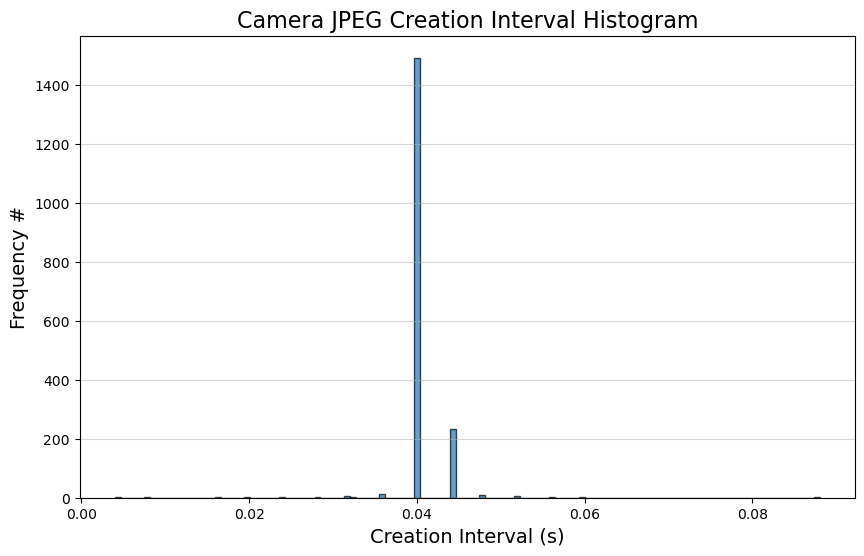

In [49]:
# 作成インターバルのヒストグラムを表示
plt.figure(figsize=(10, 6))
plt.hist(interval_ds_v0_df, bins=120, edgecolor='black', alpha=0.7)
plt.title('Camera JPEG Creation Interval Histogram', fontsize=16)
plt.xlabel('Creation Interval (s)', fontsize=14)
plt.ylabel('Frequency #', fontsize=14)
plt.grid(axis='y', alpha=0.5)

## Dataset v1

Dataset v0 のデータ構成に加え、データセット毎に dataset_v1.parquet というテーブルデータを持つ。

テーブルデータは、v0 でディレクトリ名やファイル名に埋め込んでいた情報を持ち、合わせてデータセットサンプルとしてのJPEG画像と、そのサンプルのソースとなる未処理データセット camera/ のサンプルとしてのJPEG画像の相関も記録し、camera/ dataset/ detect/ のデータセットサンプル間でのデータリネージュを追跡することができる。

In [4]:
def parquet_paths_ds_v1():
    # 収集対象である作成時間（UTCタイムスタンプ列）を含むParquetファイル群
    return chain(
        Path(asset_root()).glob("dataset/*/dataset_v1.parquet"),
        Path(asset_root()).glob("detect/*/dataset_v1.parquet"),
    )


In [5]:
def annotation_interval_stats_ds_v1(limit_hi=60, limit_lo=0.25):
    timestamp_df = pd.DataFrame({"UTCタイムスタンプ": []}, dtype="object")
    
    # 収集対象である作成時間（UTCタイムスタンプ列）を含むParquetファイル群
    parquet_paths = parquet_paths_ds_v1()
    
    # 各データセット行の作成時間（UTCタイムスタンプ列）を収集する。
    # ただし、値種別列が "y" の行は、値種別列が "x" のものに付随して作られる非推奨の情報なので収集対象から除外する。
    for f in parquet_paths:
        df = pd.read_parquet(f)
        if "値種別" in df:
            df = df[df["値種別"] != "y"]
        timestamp_df = pd.concat([timestamp_df, df["UTCタイムスタンプ"]])
    
    # 昇順にソート
    timestamp_df = timestamp_df.sort_values(by="UTCタイムスタンプ")
    
    # 同時刻タイムスタンプは考慮外にする
    timestamp_df = timestamp_df.drop_duplicates()
    
    # ISO 8601フォーマットからUNIX Epoch秒（浮動小数点あり）に変換する
    epoch_df = timestamp_df.map(lambda x: datetime.fromisoformat(x).timestamp())
    
    # 前後の作成時刻の差分をとり、作成インターバルを得る（最初の要素のNaNはドロップ）
    interval_df = epoch_df.diff().dropna()
    
    # しきい値以上の作成インターバルを無視する
    interval_df = interval_df[(interval_df["UTCタイムスタンプ"] < limit_hi) & (interval_df["UTCタイムスタンプ"] > limit_lo)]
    
    return interval_df, epoch_df


In [6]:
def sample_type_stats_ds_v1():
    sample_type_col = ["値種別", "環境カテゴリ"]
    sample_type_exclude = ["y"]
    sample_type_df = None
    
    # 収集対象であるサンプルタイプ情報（値種別、環境カテゴリ列）を含むParquetファイル群
    parquet_paths = parquet_paths_ds_v1()
    
    # 各データセット行のサンプルタイプ情報（値種別、環境カテゴリ列）を収集する。
    # ただし、値種別列が "y" の行は、値種別列が "x" のものに付随して作られる非推奨の情報なので収集対象から除外する。
    for f in parquet_paths:
        df = pd.read_parquet(f)
        for col in sample_type_col:
            if col in df:
                df = df[~df[col].isin(sample_type_exclude)][col]
                continue

        if sample_type_df is not None:
            sample_type_df = pd.concat([sample_type_df, df], ignore_index=True)
        else:
            sample_type_df = df
    
    count_df = sample_type_df.value_counts().to_frame(name="Count")
    
    return count_df


### 統計情報

In [8]:
# interval_ds_v0_df, _ = annotation_interval_stats_ds_v0(limit_hi=30)

In [9]:
# interval_ds_v0_df

In [10]:
# # 作成インターバルのヒストグラムを表示
# plt.figure(figsize=(10, 6))
# plt.hist(interval_ds_v0_df, bins=120, edgecolor='black', alpha=0.7)
# plt.title('Creation Interval Histogram', fontsize=16)
# plt.xlabel('Creation Interval (s)', fontsize=14)
# plt.ylabel('Frequency #', fontsize=14)
# plt.grid(axis='y', alpha=0.5)

In [11]:
inverval_ds_v1_df, _ = annotation_interval_stats_ds_v1(limit_hi=30)

In [12]:
inverval_ds_v1_df

,UTCタイムスタンプ
1,6.025789
10,14.043794
13,6.516375
18,5.268446
19,3.064654
...,...
122,4.884782
16,22.015682
287,4.972891
82,8.038919


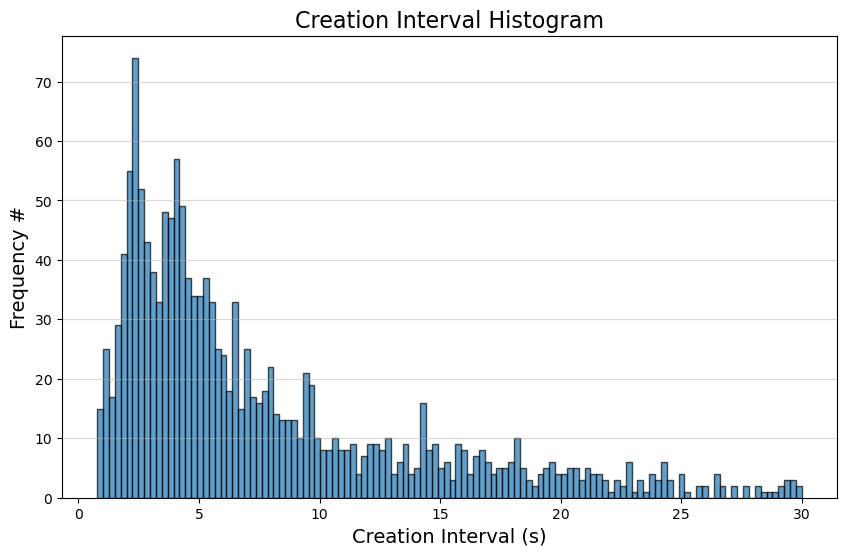

In [13]:
# 作成インターバルのヒストグラムを表示
plt.figure(figsize=(10, 6))
plt.hist(inverval_ds_v1_df, bins=120, edgecolor='black', alpha=0.7)
plt.title('Creation Interval Histogram', fontsize=16)
plt.xlabel('Creation Interval (s)', fontsize=14)
plt.ylabel('Frequency #', fontsize=14)
plt.grid(axis='y', alpha=0.5)

In [14]:
sample_type_stats_ds_v1()

,Count
x,840
speed,753
ETC,168
GATE_LEFT,109
GATE_RIGHT,93
GATE_CENTER,55
START_3,46
START_2,45
CORNER_END,43
CORNER_FIRST,43
